# <font color="brown">Naive Bayes Teaching Note </font>

## <font color = "brown">Purpose </font>
A from-scratch, detailed teaching note on the **Naive Bayes classifier**, written to be taught from. Every worked example from the source notes is reproduced here with live code that computes the actual numbers (so you can trust every figure), plus diagrams to make the intuition concrete.

## <font color = "brown">Contents </font>
1. Introduction
2. Bayes' Theorem
3. The Naive Bayes Classifier
4. Worked Example: Weather Data ("Play Tennis")
5. Handling Zero Probabilities: Laplace Smoothing
6. Strengths, Weaknesses, and When to Use Naive Bayes
7. Summary

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

## <font color="brown"> 1. Introduction

The Naive Bayes classifier is a probabilistic machine learning algorithm based on Bayes' theorem. It is called *naive* because it assumes that the features describing an instance are conditionally independent given the class label. While this assumption rarely holds exactly in real-world data, the simplification often works surprisingly well in practice, especially for problems involving high-dimensional data such as text classification.

Naive Bayes has been successfully applied to spam filtering, document categorization, medical diagnosis, and sentiment analysis. Its strengths include computational efficiency, ease of implementation, and good performance even with relatively small training datasets.

## <font color="brown"> 2. Bayes' Theorem

Bayes' theorem provides a mathematical framework for updating the probability of a hypothesis in light of new evidence.

### <font color="blue"> Mathematical Form

$$P(h \mid D) = \frac{P(D \mid h) \cdot P(h)}{P(D)}$$

Where:

* $P(h)$ is the **prior** probability of the hypothesis $h$, before observing any data.
* $P(D \mid h)$ is the **likelihood**, the probability of observing data $D$ if $h$ is true.
* $P(D)$ is the **evidence**, the overall probability of observing data $D$, across every possible hypothesis.
* $P(h \mid D)$ is the **posterior**, the updated probability of $h$ after observing $D$, this is what we're actually trying to compute.

In words: *start with what you believed before (the prior), see how well the evidence fits that belief (the likelihood), and end up with an updated belief (the posterior).*

### <font color="blue"> Intuitive Example: Two Bags of Balls

Imagine two bags of balls:

| Bag | Red Balls | Blue Balls |
| --- | --- | --- |
| A | 7 | 3 |
| B | 4 | 6 |

You pick one of the two bags at random (so each is equally likely), then draw a ball from it *without looking at the bag*. The ball turns out to be **red**. Which bag did it more likely come from?

* $P(A) = 0.5$ (the prior, before we saw the ball, both bags were equally likely)
* $P(\text{Red} \mid A) = 7/10 = 0.7$ (the likelihood, if it is Bag A, 70% of its balls are red)
* $P(\text{Red}) = P(\text{Red}\mid A)P(A) + P(\text{Red}\mid B)P(B) = (0.7 \times 0.5) + (0.4 \times 0.5) = 0.55$ (the evidence, overall probability of drawing red, from *either* bag)
* $P(A \mid \text{Red}) = \dfrac{0.7 \times 0.5}{0.55} \approx 0.636$ (the posterior)

So after seeing a red ball, our belief that it came from Bag A rises from 50% to about 63.6%.

In [6]:
p_a = 0.5
p_b = 0.5
p_red_given_a = 7 / 10
p_red_given_b = 4 / 10

p_red = p_red_given_a * p_a + p_red_given_b * p_b
p_a_given_red = (p_red_given_a * p_a) / p_red
p_b_given_red = (p_red_given_b * p_b) / p_red

print("P(Red) =", p_red)
print("P(A | Red) =", p_a_given_red)
print("P(B | Red) =", p_b_given_red)

P(Red) = 0.55
P(A | Red) = 0.6363636363636362
P(B | Red) = 0.36363636363636365


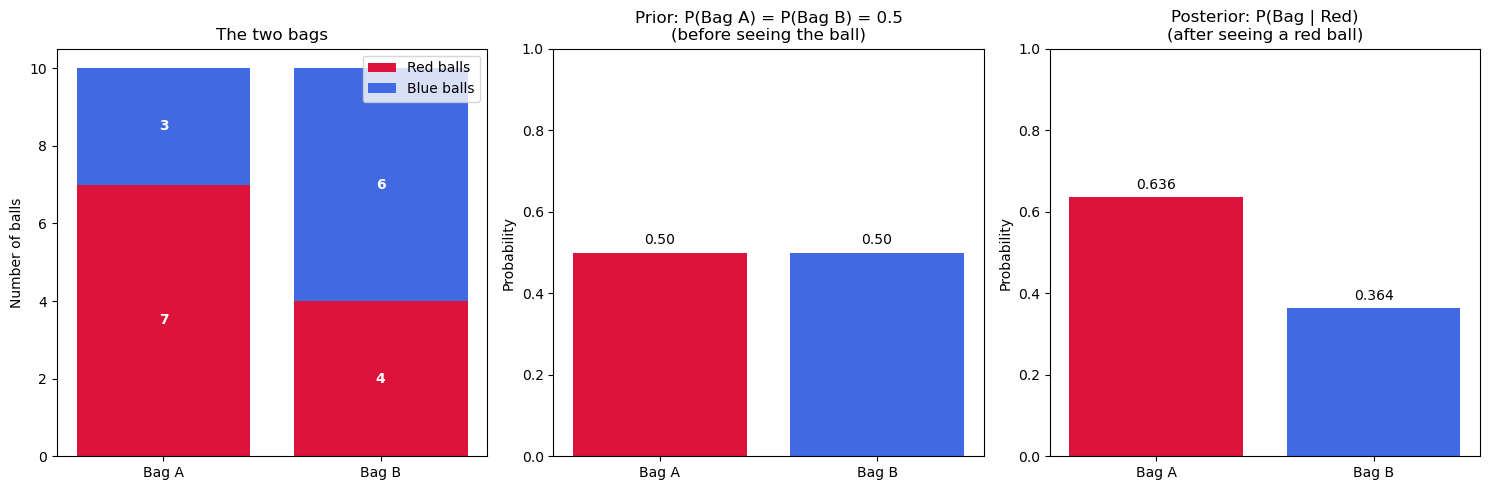

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

bags = ['Bag A', 'Bag B']
red = [7, 4]
blue = [3, 6]

ax = axes[0]
x = np.arange(2)
ax.bar(x, red, color='crimson', label='Red balls')
ax.bar(x, blue, bottom=red, color='royalblue', label='Blue balls')
ax.set_xticks(x)
ax.set_xticklabels(bags)
ax.set_ylabel('Number of balls')
ax.set_title('The two bags')
ax.legend()
for i in range(2):
    ax.text(i, red[i] / 2, str(red[i]), ha='center', va='center', color='white', fontweight='bold')
    ax.text(i, red[i] + blue[i] / 2, str(blue[i]), ha='center', va='center', color='white', fontweight='bold')

ax = axes[1]
ax.bar(bags, [p_a, p_b], color=['crimson', 'royalblue'])
ax.set_ylim(0, 1)
ax.set_title('Prior: P(Bag A) = P(Bag B) = 0.5\n(before seeing the ball)')
ax.set_ylabel('Probability')
for i, v in enumerate([p_a, p_b]):
    ax.text(i, v + 0.02, f'{v:.2f}', ha='center')

ax = axes[2]
post = [p_a_given_red, p_b_given_red]
ax.bar(bags, post, color=['crimson', 'royalblue'])
ax.set_ylim(0, 1)
ax.set_title('Posterior: P(Bag | Red)\n(after seeing a red ball)')
ax.set_ylabel('Probability')
for i, v in enumerate(post):
    ax.text(i, v + 0.02, f'{v:.3f}', ha='center')

plt.tight_layout()
plt.show()

This is the whole idea of Bayes' theorem in one picture: we start with a flat, uninformed belief (50/50), and the evidence (drawing a red ball, which is more common in Bag A) tilts that belief towards Bag A.

## <font color="brown"> 3. The Naive Bayes Classifier

### <font color="blue"> The Naive Independence Assumption

In classification, our "hypothesis" is which class $v_j$ an instance belongs to, and our "data" is the instance's feature vector $X = \langle a_1, a_2, \ldots, a_n \rangle$. Applying Bayes' theorem directly:

$$P(v_j \mid a_1, a_2, \ldots, a_n) = \frac{P(a_1, a_2, \ldots, a_n \mid v_j) \, P(v_j)}{P(a_1, a_2, \ldots, a_n)}$$

The problem: estimating $P(a_1, a_2, \ldots, a_n \mid v_j)$ directly would need enough training examples to cover every *combination* of feature values, which grows explosively with the number of features. This is where the **naive assumption** comes in: assume the features are conditionally independent of each other, given the class. That lets us break the joint probability into a simple product:

$$P(a_1, a_2, \ldots, a_n \mid v_j) = \prod_{i} P(a_i \mid v_j)$$

Instead of needing examples of every combination, we only ever need to estimate each feature's probability *on its own*, given the class, which needs far less data.

### <font color="blue"> Classification Rule

Since $P(a_1, \ldots, a_n)$ (the evidence) is the same number regardless of which class we're considering, it doesn't affect *which* class scores highest, so we can drop it and simply pick whichever class maximises the numerator:

$$v_{NB} = \underset{v_j}{\operatorname{argmax}} \; P(v_j) \prod_{i} P(a_i \mid v_j)$$

In words: for every candidate class, multiply its prior probability by the probability of each observed feature value given that class, then pick the class with the largest result.

## <font color="brown"> 4. Worked Example: Weather Data ("Play Tennis")

We illustrate the Naive Bayes classifier using the classic "Play Tennis" dataset, predicting whether someone plays tennis based on the day's weather.

In [11]:
data = {
    'Outlook':     ['Sunny','Sunny','Overcast','Rain','Rain','Rain','Overcast',
                    'Sunny','Sunny','Rain','Sunny','Overcast','Overcast','Rain'],
    'Temperature': ['Hot','Hot','Hot','Mild','Cool','Cool','Cool',
                    'Mild','Cool','Mild','Mild','Mild','Hot','Mild'],
    'Humidity':    ['High','High','High','High','Normal','Normal','Normal',
                    'High','Normal','Normal','Normal','High','Normal','High'],
    'Windy':       [False,True,False,False,False,True,True,
                    False,False,False,True,True,False,True],
    'Class':       ['Not Play','Not Play','Play','Play','Play','Not Play','Play',
                    'Not Play','Play','Play','Play','Play','Play','Not Play'],
}
df = pd.DataFrame(data)
df

,Outlook,Temperature,Humidity,Windy,Class
0,Sunny,Hot,High,False,Not Play
1,Sunny,Hot,High,True,Not Play
2,Overcast,Hot,High,False,Play
3,Rain,Mild,High,False,Play
4,Rain,Cool,Normal,False,Play
5,Rain,Cool,Normal,True,Not Play
6,Overcast,Cool,Normal,True,Play
7,Sunny,Mild,High,False,Not Play
8,Sunny,Cool,Normal,False,Play
9,Rain,Mild,Normal,False,Play


### <font color="blue"> Step 1: Prior Probabilities

In [13]:
p_play = (df['Class'] == 'Play').mean()
p_notplay = (df['Class'] == 'Not Play').mean()

print(f"P(Play)     = {p_play:.4f}")
print(f"P(Not Play) = {p_notplay:.4f}")

P(Play)     = 0.6429
P(Not Play) = 0.3571


### <font color="blue"> Step 2: Conditional Probability Tables

For each feature, we compute the probability of each of its values, separately within the "Play" rows and the "Not Play" rows.

In [15]:
for feature in ['Outlook', 'Temperature', 'Humidity', 'Windy']:
    table = pd.crosstab(df[feature], df['Class'], normalize='columns')[['Play', 'Not Play']]
    print(f"\n{feature}:")
    print(table.round(4))


Outlook:
Class       Play  Not Play
Outlook                   
Overcast  0.4444       0.0
Rain      0.3333       0.4
Sunny     0.2222       0.6

Temperature:
Class          Play  Not Play
Temperature                  
Cool         0.3333       0.2
Hot          0.2222       0.4
Mild         0.4444       0.4

Humidity:
Class       Play  Not Play
Humidity                  
High      0.3333       0.8
Normal    0.6667       0.2

Windy:
Class    Play  Not Play
Windy                  
False  0.6667       0.4
True   0.3333       0.6


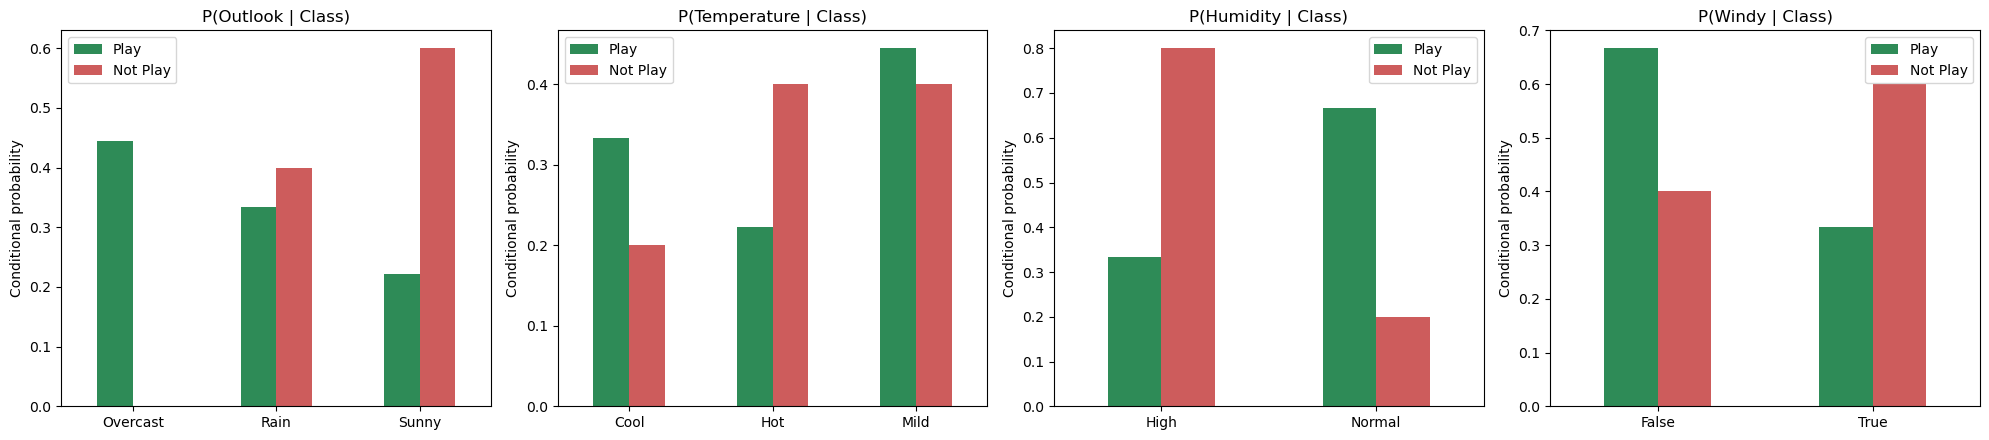

In [16]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
for ax, feature in zip(axes, ['Outlook', 'Temperature', 'Humidity', 'Windy']):
    ct = pd.crosstab(df[feature], df['Class'], normalize='columns')[['Play', 'Not Play']]
    ct.plot(kind='bar', ax=ax, color=['seagreen', 'indianred'])
    ax.set_title(f'P({feature} | Class)')
    ax.set_ylabel('Conditional probability')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=0)
    ax.legend(title='')
plt.tight_layout()
plt.show()

One bar is worth pausing on: **`Outlook = Overcast` never occurs on a "Not Play" day** in this data, its bar is completely missing on the red side. That gives $P(\text{Overcast} \mid \text{Not Play}) = 0$, a real zero probability sitting right in our own table. We'll come back to exactly why that's a problem in Section 5.

### <font color="blue"> Step 3: Predicting a New Instance

Now, let's predict the class for a new day: $X = \langle \text{Rain}, \text{Hot}, \text{High}, \text{False} \rangle$.

$$P(\text{Play} \mid X) \propto P(\text{Rain}\mid\text{Play}) \, P(\text{Hot}\mid\text{Play}) \, P(\text{High}\mid\text{Play}) \, P(\text{False}\mid\text{Play}) \, P(\text{Play})$$
$$= \tfrac{3}{9} \times \tfrac{2}{9} \times \tfrac{3}{9} \times \tfrac{6}{9} \times \tfrac{9}{14} \approx 0.0106$$

$$P(\text{Not Play} \mid X) \propto P(\text{Rain}\mid\text{NP}) \, P(\text{Hot}\mid\text{NP}) \, P(\text{High}\mid\text{NP}) \, P(\text{False}\mid\text{NP}) \, P(\text{Not Play})$$
$$= \tfrac{2}{5} \times \tfrac{2}{5} \times \tfrac{4}{5} \times \tfrac{2}{5} \times \tfrac{5}{14} \approx 0.0183$$

In [19]:
score_play = (3/9) * (2/9) * (3/9) * (6/9) * p_play
score_notplay = (2/5) * (2/5) * (4/5) * (2/5) * p_notplay

print(f"Unnormalized score, Play:     {score_play:.4f}")
print(f"Unnormalized score, Not Play: {score_notplay:.4f}")

Unnormalized score, Play:     0.0106
Unnormalized score, Not Play: 0.0183


### <font color="blue"> Step 4: Normalizing

These two numbers are proportional to the true posteriors, but they don't sum to 1, we've been ignoring the shared denominator $P(X)$ (the evidence) from Bayes' theorem, since it's identical for both classes and doesn't change which one wins. To turn them into genuine probabilities that sum to 1, we divide each by their total, this is exactly the same normalizing step as in the bags example above:

$$P(\text{Play} \mid X) = \frac{0.0106}{0.0106 + 0.0183} \approx 0.3665, \qquad P(\text{Not Play} \mid X) = \frac{0.0183}{0.0106 + 0.0183} \approx 0.6334$$

In [21]:
total = score_play + score_notplay
posterior_play = score_play / total
posterior_notplay = score_notplay / total

print(f"P(Play | X)     = {posterior_play:.4f}  ({posterior_play*100:.2f}%)")
print(f"P(Not Play | X) = {posterior_notplay:.4f}  ({posterior_notplay*100:.2f}%)")

predicted_class = "Play" if posterior_play > posterior_notplay else "Not Play"
print(f"\nPredicted class: {predicted_class}")

P(Play | X)     = 0.3666  (36.66%)
P(Not Play | X) = 0.6334  (63.34%)

Predicted class: Not Play


Since $63.34\% > 36.66\%$, sample $X = \langle \text{Rain}, \text{Hot}, \text{High}, \text{False} \rangle$ is classified as **Not Play**.

## <font color="brown"> 5. Handling Zero Probabilities: Laplace Smoothing

A common problem arises when a particular feature value never occurs with a given class in the training set, its estimated probability comes out as exactly zero. We already spotted this: $P(\text{Overcast} \mid \text{Not Play}) = 0/5 = 0$ in our own weather data.

Why is this a real problem, and not just a curiosity? Because Naive Bayes **multiplies** the feature probabilities together. If even one of them is zero, the *entire* product becomes zero, no matter how strongly every other feature points the other way. In practice, this means: any day with `Outlook = Overcast` can *never* be classified as "Not Play", regardless of how bad the rest of the weather looks.

In [24]:
# demonstrating the problem directly: any Overcast day scores exactly 0 for Not Play,
# no matter what the other three features are
p_overcast_given_notplay = 0 / 5
example_score = p_overcast_given_notplay * (2/5) * (4/5) * (2/5) * p_notplay
print("Score for Not Play, any Overcast day:", example_score)

Score for Not Play, any Overcast day: 0.0


### <font color="blue"> The Fix: Laplace Smoothing

Laplace smoothing (also called *add-one smoothing*) fixes this by pretending we saw one extra example of every possible feature value, for every class:

$$P(a_i \mid v_j) = \frac{\text{count}(a_i, v_j) + 1}{\text{count}(v_j) + k}$$

where $k$ is the number of distinct possible values that feature $a_i$ can take. Adding 1 to every count means no probability can ever come out as exactly zero, while the $+k$ in the denominator keeps everything correctly normalized (the probabilities across all $k$ values of that feature still sum to 1).

### <font color="blue"> Example 1: A Never-Seen Value ("Snowy")

Suppose `Outlook` could also take the value "Snowy", and it never appeared in the "Play" class. The unsmoothed probability would be $0/9 = 0$. With Laplace smoothing, and $k=4$ possible Outlook values (Sunny, Overcast, Rain, Snowy):

In [27]:
count_snowy_play = 0
count_play = 9
k = 4  # Sunny, Overcast, Rain, Snowy

unsmoothed = count_snowy_play / count_play
smoothed = (count_snowy_play + 1) / (count_play + k)

print(f"Unsmoothed P(Snowy | Play): {unsmoothed}")
print(f"Smoothed P(Snowy | Play):   {smoothed:.4f}")

Unsmoothed P(Snowy | Play): 0.0
Smoothed P(Snowy | Play):   0.0769


### <font color="blue"> Example 2: Fixing Our Own Overcast/Not Play Zero

Let's apply the same fix to the real zero we found in our own data, $P(\text{Overcast} \mid \text{Not Play})$, where $k=3$ (Sunny, Overcast, Rain are the only Outlook values that actually occur in this dataset).

In [29]:
count_overcast_notplay = 0
count_notplay = 5
k_outlook = 3  # Sunny, Overcast, Rain

unsmoothed = count_overcast_notplay / count_notplay
smoothed = (count_overcast_notplay + 1) / (count_notplay + k_outlook)

print(f"Unsmoothed P(Overcast | Not Play): {unsmoothed}")
print(f"Smoothed P(Overcast | Not Play):   {smoothed:.4f}")

Unsmoothed P(Overcast | Not Play): 0.0
Smoothed P(Overcast | Not Play):   0.1250


A small, non-zero probability instead of a hard zero, an Overcast day can now still, in principle, be classified as "Not Play" if every other feature strongly suggests it, it's just treated as unlikely rather than impossible.

## <font color="brown"> 6. Strengths, Weaknesses, and When to Use Naive Bayes

**Strengths**
* Extremely fast to train and predict, just counting and multiplying, no iterative optimization.
* Works well even with relatively little training data.
* Handles high-dimensional data gracefully (e.g. thousands of words in text classification), since each feature is handled independently.
* Naturally handles categorical features, and multi-class problems, without any extra machinery.

**Weaknesses**
* The independence assumption is rarely true in practice, correlated features (e.g. `Humidity` and `Outlook`, which are often related) get double-counted, which can bias the probabilities.
* Needs Laplace smoothing (or a similar fix) to avoid the zero-probability problem in Section 5.
* The predicted probabilities themselves are often poorly calibrated (the class ranking tends to be reliable even when the exact percentages aren't).

**Rule of thumb**: reach for Naive Bayes as a fast, strong baseline, especially for text/categorical data, or whenever you need something that trains quickly on a large number of features. If features are heavily correlated with each other, models that don't assume independence (like Decision Trees or Logistic Regression) will usually do better.

## <font color="brown"> 7. Summary

Naive Bayes is a classification technique based on Bayes' theorem with an assumption of feature independence. It is fast, simple, and effective for many applications, especially with categorical data and high-dimensional feature spaces. Laplace smoothing ensures robustness against unseen feature values, with $k$ representing the number of possible values for each feature.

Naive Bayes classifiers are easy to implement, and good results are obtained in most cases where the data has a lot of categorical independent variables.